<a href="https://colab.research.google.com/github/tomasrodriguezr11/Programacion-MIAAD/blob/main/ProyectoEDA_266228.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto: Análisis Exploratorio de Datos (EDA)**
**Programación para Analítica Descriptiva y Predictiva - Maestría en Inteligencia Artificial y Analítica de Datos**

*Realizada por: Tomás Eduardo Rodríguez Ramírez*

*Número de matrícula: 266228*

**Objetivo**

Realizar un Análisis Exploratorio de Datos (EDA) utilizando Python en Google Colab, aplicando técnicas de preprocesamiento, estadística descriptiva y visualización para identificar patrones, relaciones y problemas en los datos.

# **1. Descripción del dataset**

**Origen:** Escober, E. and Espino, M.P. (2023). A new trophic state index for assessing eutrophication of Laguna de Bay, Philippines. Environmental Advances, Vol. 13, 100410. doi: 10.1016/j.envadv.2023.100410. Enlace: https://github.com/kspilario/MLxChE/blob/main/Week-07-Neural-Nets/chlor.csv

**Descripción:** Dataset ambiental relacionado con clorofila (Chl_a), fitoplancton (Phy) y nutrientes (NO2, NO3, NH4, PO4) medidos en diferentes sitios y bahías.

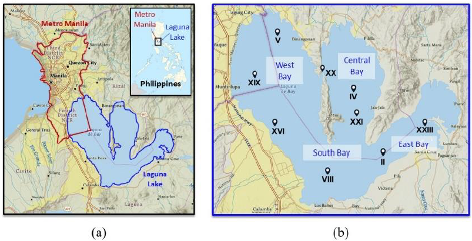

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset="drive/MyDrive/ProgramacionMIAAD/chlor.csv"
df = pd.read_csv(dataset, skipfooter=1, engine='python')
df

,Chl_a,Phy,NO2,NO3,NH4,PO4,Site,Bay,Depth
0,6.66,0.74,0.21830,0.522735,31.784807,15.317651,XVI,West Bay,1.097
1,6.45,0.78,0.21830,0.522735,31.784807,15.317651,XVI,West Bay,1.098
2,6.27,0.77,0.21830,0.522735,31.784807,15.317651,XVI,West Bay,1.098
3,6.13,0.58,0.21495,0.527931,30.446107,14.834307,XVI,West Bay,2.004
4,6.10,0.57,0.21495,0.527931,30.446107,14.834307,XVI,West Bay,2.004
...,...,...,...,...,...,...,...,...,...
249,5.64,0.62,0.21221,0.634104,31.311913,15.862311,VIII,South Bay,3.002
250,5.79,0.57,0.21221,0.634104,31.311913,15.862311,VIII,South Bay,3.003
251,5.26,0.55,0.21221,0.634104,31.311913,15.862311,VIII,South Bay,3.004
252,5.77,0.52,0.21221,0.634104,31.311913,15.862311,VIII,South Bay,3.007


In [ ]:
print("Dimensiones:", df.shape)

Dimensiones: (254, 9)


- **Descripción de las variables:**

  - **Chl_a (Clorofila a):** Representa la concentración de clorofila en el agua. Es un indicador de la biomasa fitoplanctónica y la productividad primaria del ecosistema acuático.

  - **Phy (Fitoplancton):** Indica la abundancia o biomasa del fitoplancton presente en la muestra. Está directamente relacionada con procesos ecológicos como la fotosíntesis y la disponibilidad de nutrientes.

  - **NO2 (Nitrito):** Concentración de nitrito disuelto en el agua. Forma parte del ciclo del nitrógeno y puede indicar procesos de nitrificación o contaminación.

  - **NO3 (Nitrato):** Concentración de nitrato. Es uno de los nutrientes principales para el crecimiento del fitoplancton y suele estar asociado a aportes terrestres o mezcla vertical.

  - **NH4 (Amonio):** Concentración de amonio disuelto. Es una forma de nitrógeno altamente disponible biológicamente, utilizada rápidamente por organismos fotosintéticos.

  - **PO4 (Fosfato):** Concentración de fosfato. Es un nutriente esencial que puede limitar la productividad primaria en ecosistemas acuáticos.

  - **Depth (Profundidad):** Profundidad a la que fue tomada la muestra. Puede influir en variables como luz disponible, temperatura y concentración de nutrientes.

  - **Site (Sitio de muestreo):** Variable categórica que identifica el punto específico donde se realizó la medición.

  - **Bay (Bahía):** Variable categórica que indica la bahía o zona geográfica general del muestreo.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Chl_a   254 non-null    float64
 1   Phy     254 non-null    float64
 2   NO2     109 non-null    float64
 3   NO3     109 non-null    float64
 4   NH4     109 non-null    float64
 5   PO4     109 non-null    float64
 6   Site    254 non-null    object 
 7   Bay     254 non-null    object 
 8   Depth   254 non-null    float64
dtypes: float64(7), object(2)
memory usage: 18.0+ KB
None


# **2. Revisión de calidad de datos**

In [ ]:
# Valores faltantes
print(df.isna().sum())

Chl_a      0
Phy        0
NO2      145
NO3      145
NH4      145
PO4      145
Site       0
Bay        0
Depth      0
dtype: int64


In [ ]:
# Valores duplicados
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


In [ ]:
# Nombres de columnas
print(df.columns)

Index(['Chl_a', 'Phy', 'NO2', 'NO3', 'NH4', 'PO4', 'Site', 'Bay', 'Depth'], dtype='object')


**Observaciones:**
- Las variables NO2, NO3, NH4, PO4 tienen 145 valores faltantes
- No existen valores duplicados
- Los nombres de las columnas parecen correctos

# **3. Proprocesamiento de datos**

**Datos faltantes**

Durante la revisión de calidad de datos se detectó una cantidad considerable de valores faltantes en las variables de nutrientes (NO2, NO3, NH4 y PO4). Inicialmenta, se evaluó la eliminación de registros incompletos; sin embargo, se optó por aplicar imputación mediante la mediana por las siguientes razones:

- Los valores faltantes representaban más del 50 % de las observaciones en algunas variables.
- La eliminación de filas habría reducido significativamente el tamaño del dataset.
- Se habría perdido información importante de otras variables relevantes como clorofila y fitoplancton.
- La reducción del número de datos puede afectar la confiabilidad del análisis exploratorio.
- La mediana es una medida robusta frente a valores atípicos, por lo que permite completar los datos sin alterar notablemente su distribución.


In [ ]:
nutrientes = ['NO2','NO3','NH4','PO4']

for col in nutrientes:
    df[col] = df[col].fillna(df[col].median())

**Detección de Outliers usando boxplots**

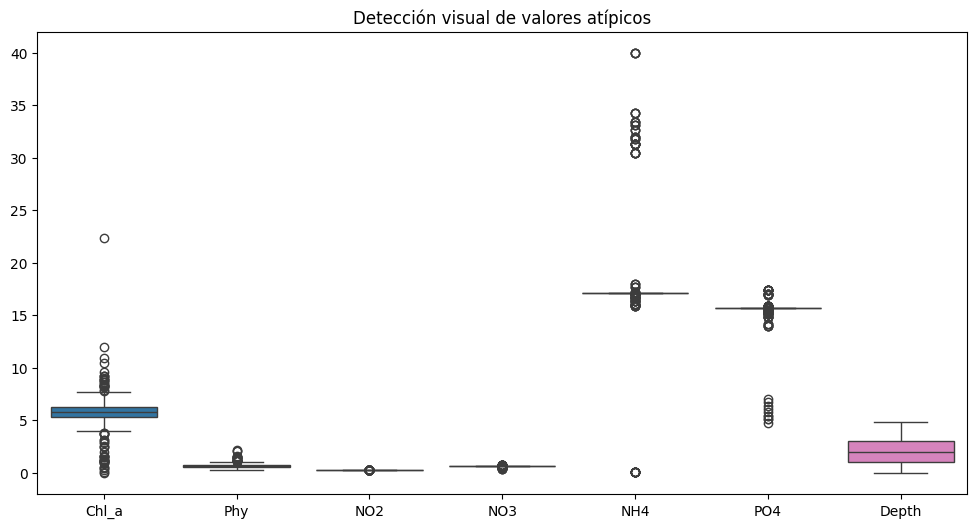

In [ ]:
num_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.title("Detección visual de valores atípicos")
plt.show()

**Observaciones:**
- NH4 presenta la mayor dispersión y numerosos valores extremos superiores, lo que indica alta variabilidad en la concentración de amonio.
- PO4 también muestra presencia importante de valores atípicos, tanto por encima como por debajo del rango intercuartílico.
- Chl_a presenta algunos valores extremos superiores, asociados a posibles eventos puntuales de alta productividad biológica.
- Phy muestra variabilidad moderada y menor número de valores atípicos en comparación con NH4 y PO4.
- NO2 y NO3 presentan baja dispersión visual, concentrándose la mayoría de sus valores alrededor de la mediana.
- Depth no evidencia valores atípicos, lo que sugiere un rango de muestreo relativamente uniforme.

En general, las variables de nutrientes muestran mayor heterogeneidad y asimetría que las variables físicas, lo cual es consistente con la dinámica natural de los sistemas acuáticos.

**Detección de Outliers usando Rango Intercuartílico (IQR)**

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, "Outliers:", outliers.shape[0])

Chl_a Outliers: 60
Phy Outliers: 22
NO2 Outliers: 93
NO3 Outliers: 105
NH4 Outliers: 106
PO4 Outliers: 102
Depth Outliers: 0


**Observaciones:**

- El método del rango intercuartílico muestra que las variables de nutrientes (NO2, NO3, NH4 y PO4) presentan el mayor número de valores atípicos.
- Esto sugiere distribuciones altamente asimétricas y presencia de concentraciones extremas en algunas observaciones.
- En contraste, las variables biológicas como Chl_a y Phy presentan menor cantidad de valores extremos, mientras que Depth no evidencia valores atípicos.
- Este comportamiento puede estar asociado a la alta variabilidad natural de los nutrientes en sistemas acuáticos y al efecto de la imputación de valores faltantes sobre la dispersión de los datos.

# **4. Análisis univariado**

**Estadística descriptiva**

In [ ]:
print(df.describe())

            Chl_a         Phy         NO2         NO3         NH4         PO4  \
count  254.000000  254.000000  254.000000  254.000000  254.000000  254.000000   
mean     5.636378    0.691417    0.212451    0.618079   18.615009   15.313246   
std      2.198132    0.278337    0.004602    0.066538    7.299916    2.020592   
min     -0.050000    0.240000    0.203076    0.381999    0.015530    4.741473   
25%      5.302500    0.530000    0.212210    0.636137   17.078520   15.663037   
50%      5.770000    0.620000    0.212210    0.636137   17.078520   15.663037   
75%      6.292500    0.740000    0.212210    0.636137   17.078520   15.663037   
max     22.340000    2.200000    0.235958    0.732823   39.961437   17.424538   

            Depth  
count  254.000000  
mean     2.056988  
std      1.230973  
min      0.001000  
25%      1.046000  
50%      2.002000  
75%      2.971500  
max      4.787000  


**Observaciones:**
- Las variables Chl_a y Phy presentan valores máximos considerablemente superiores a la media, lo que indica alta dispersión y presencia de valores extremos.

- Las variables de nutrientes (NO2, NO3, NH4 y PO4) muestran medias relativamente bajas, lo cual es consistente con concentraciones típicas en sistemas acuáticos.

- NH4 presenta una desviación estándar elevada, sugiriendo mayor variabilidad en comparación con otros nutrientes.

- La variable Depth muestra menor variabilidad relativa, indicando que las muestras fueron tomadas dentro de un rango de profundidad relativamente acotado.

**Histogramas**

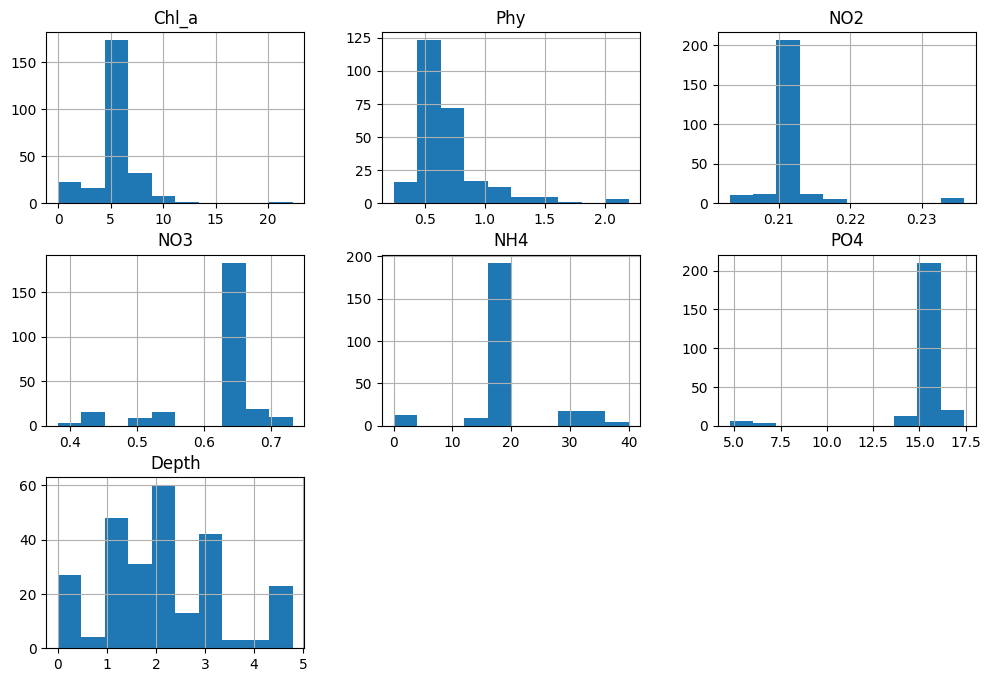

In [ ]:
df.hist(figsize=(12,8))
plt.show()

**Observaciones:**
- Chl_a presenta una distribución asimétrica positiva, lo que indica que la mayoría de las observaciones se concentran en valores bajos con algunos valores altos aislados.
- Phy muestra comportamiento similar, reflejando eventos puntuales de alta biomasa fitoplanctónica.
- Las variables de nutrientes presentan distribuciones sesgadas hacia valores bajos, lo cual es común en datos ambientales.
- Depth presenta una distribución más uniforme, sin acumulación marcada en un intervalo específico.

**Gráfico de barras**

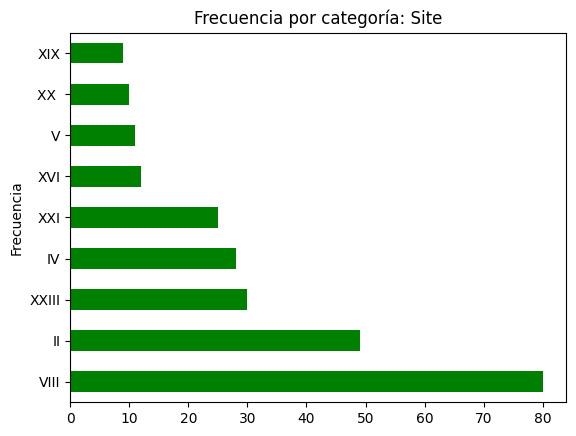

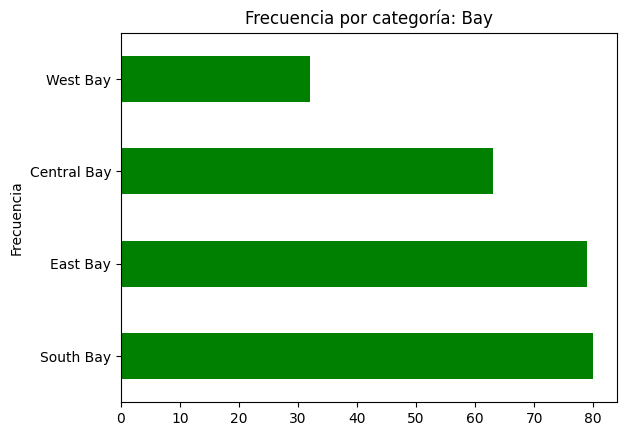

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind="barh", color='green')
    plt.title(f"Frecuencia por categoría: {col}")
    plt.ylabel("Frecuencia")
    plt.show()

**Observaciones:**
- La variable Site muestra diferencias en el número de observaciones por sitio de muestreo, lo cual puede influir en el análisis comparativo entre zonas.
- La variable Bay también presenta distribución desigual, indicando que algunas bahías fueron muestreadas con mayor frecuencia.
- Esta variabilidad en la cantidad de datos por categoría debe considerarse al interpretar resultados posteriores, especialmente en análisis bivariados.

# **5. Análisis bivariado**

**Scatter: Clorofila vs Fitoplancton**

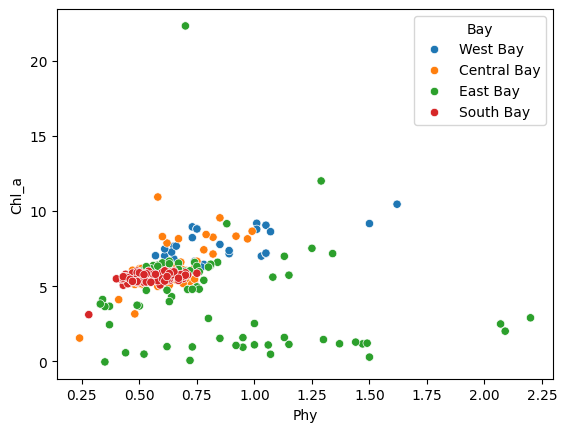

In [ ]:
sns.scatterplot(x="Phy", y="Chl_a", hue="Bay", data=df)
plt.show()

**Observaciones:**
- No se observa una relación lineal clara entre la concentración de clorofila y el fitoplancton.
- Existe alta dispersión de los datos, lo que sugiere influencia de otros factores ambientales.
- Algunas observaciones de East Bay presentan valores extremos, indicando eventos puntuales de alta productividad.

**Boxplot por Bahía**

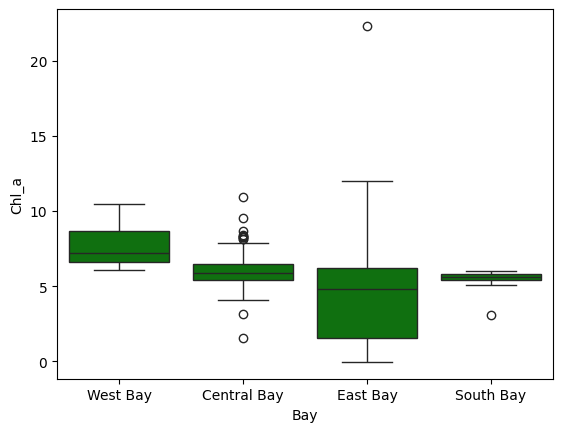

In [ ]:
sns.boxplot(x="Bay", y="Chl_a", data=df, color='green')
plt.show()

**Observaciones:**
- East Bay presenta la mayor variabilidad en la concentración de clorofila, incluyendo valores extremos superiores.
- West Bay muestra medianas ligeramente más altas, indicando mayores concentraciones típicas de clorofila.
- South Bay presenta baja dispersión, lo que sugiere condiciones más estables.
- Central Bay evidencia algunos valores atípicos inferiores y superiores, indicando variabilidad moderada entre observaciones.

# **6. Análisis multivariado**

**Matriz de correlación**

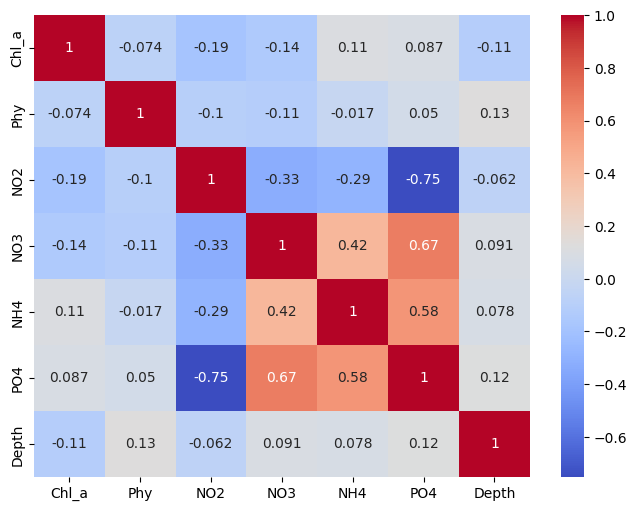

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

**Pairplot**

**Observaciones:**
- Se observa una correlación positiva moderada entre NO3, NH4 y PO4
- Existe una correlación negativa fuerte entre NO2 y PO4
- La variable Chl_a no muestra correlación significativa con Phy ni con nutrientes, lo que sugiere relaciones no lineales o influencia de otros factores ambientales.
- Depth presenta correlaciones bajas con el resto de variables

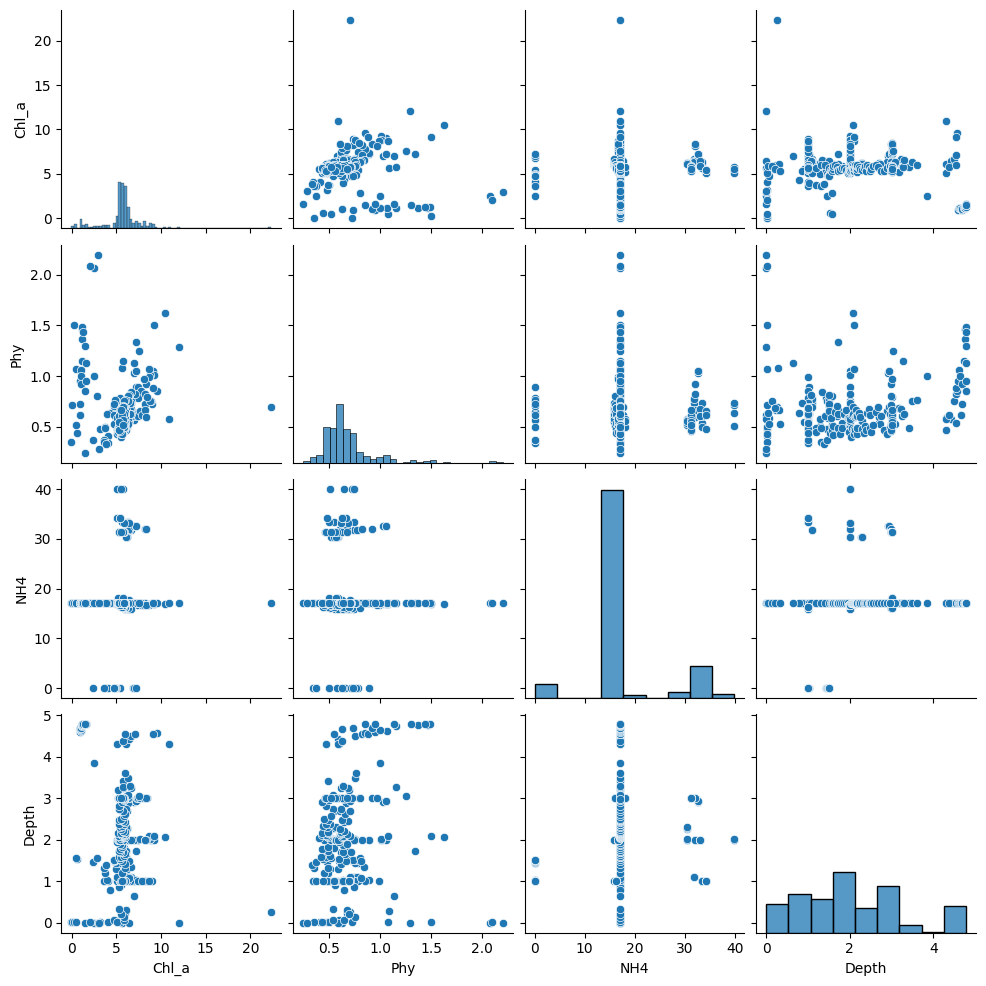

In [ ]:
sns.pairplot(df[['Chl_a','Phy','NH4','Depth']])
plt.show()

**PCA**

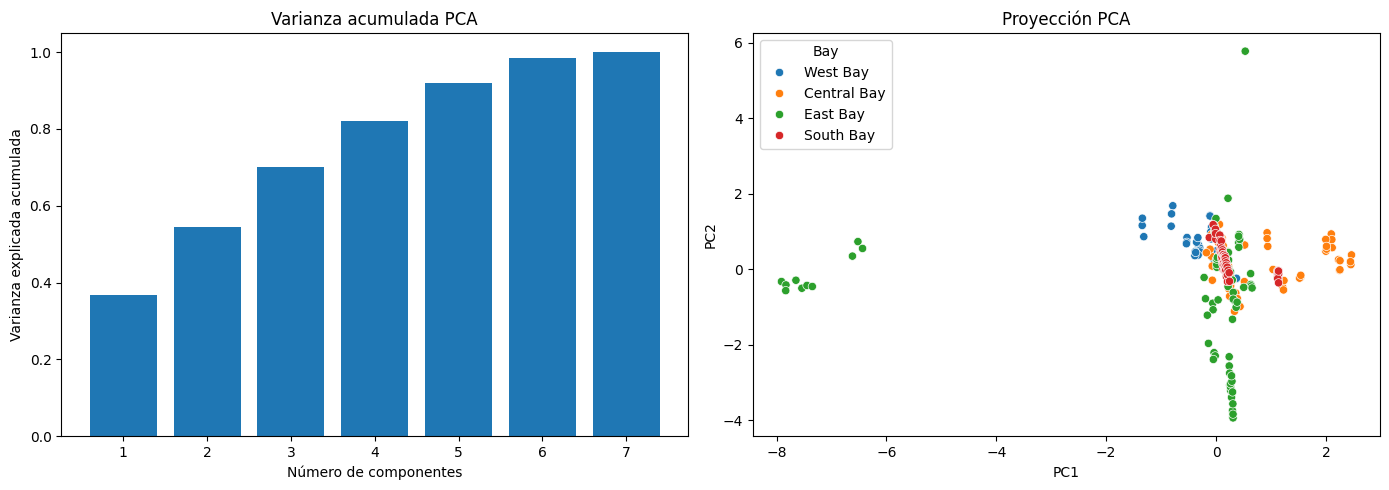

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X = df[num_cols]

# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
pca.fit(X_scaled)

pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

var_acum = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].bar(range(1, len(var_acum)+1), var_acum)
ax[0].set_xlabel("Número de componentes")
ax[0].set_ylabel("Varianza explicada acumulada")
ax[0].set_title("Varianza acumulada PCA")
ax[0].set_ylim(0,1.05)

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["Bay"],
    ax=ax[1]
)

ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
ax[1].set_title("Proyección PCA")

plt.tight_layout()
plt.show()

**Observaciones:**
- La varianza explicada acumulada muestra que los primeros tres componentes concentran gran parte de la información del dataset.
- La proyección en PC1 y PC2 permite observar dispersión y posibles agrupamientos asociados a las diferentes bahías o sitios.
- Algunos puntos alejados del centro sugieren condiciones ambientales particulares o eventos extremos.

# **7. Visualizaciones para responder preguntas**

**¿Existe relación entre la concentración de amonio y la clorofila?**

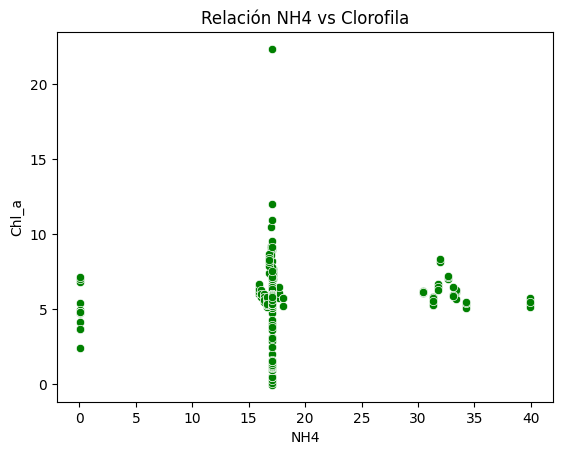

In [ ]:
sns.scatterplot(x="NH4", y="Chl_a", data=df, color='green')
plt.title("Relación NH4 vs Clorofila")
plt.show()

**Interpretación:**
- Se aprecia una tendencia positiva débil, indicando que mayores concentraciones de amonio podrían asociarse con incrementos en la clorofila.

**¿La profundidad afecta la clorofila?**

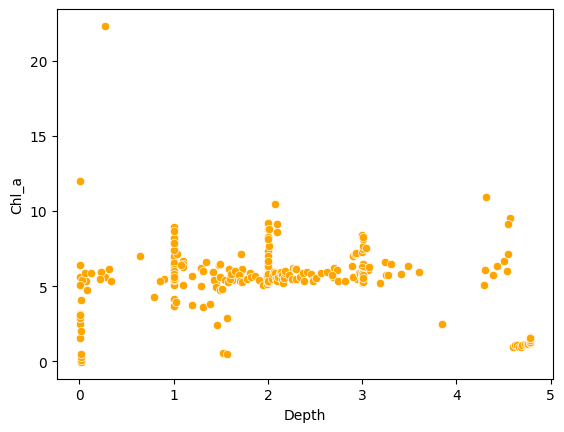

In [ ]:
sns.scatterplot(x="Depth", y="Chl_a", data=df, color='orange')
plt.show()

**Interpretación:**
- No se observa relación fuerte.

**¿Cómo se distribuye la profundidad de muestreo entre los sitios?**

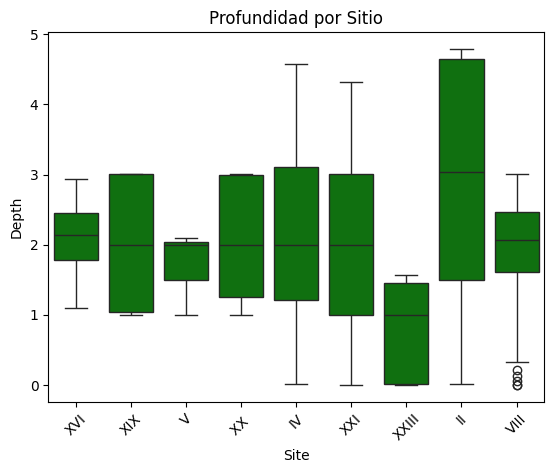

In [ ]:
sns.boxplot(x="Site", y="Depth", data=df, color='green')
plt.title("Profundidad por Sitio")
plt.xticks(rotation=45)
plt.show()

**Interpretación:**
- La profundidad de muestreo varía entre sitios, aunque sin cambios extremos, lo que indica condiciones relativamente homogéneas en la toma de muestras.

# **8. Conclusiones**

- El conjunto de datos presenta valores faltantes principalmente en variables de nutrientes, lo que requiere estrategias de preprocesamiento como imputación o análisis de impacto en el modelado predictivo.
- La concentración de clorofila no muestra una correlación lineal fuerte con el fitoplancton, lo que sugiere la posible influencia de factores ambientales adicionales o relaciones no lineales entre variables biológicas.
- Se identifican valores atípicos relevantes en clorofila y amonio (NH4), los cuales podrían estar asociados a eventos puntuales de alta productividad biológica o condiciones ambientales particulares.
- Las variables de nutrientes (NO3, NH4 y PO4) presentan correlaciones positivas moderadas entre sí. Asimismo, se observa una correlación negativa fuerte entre NO2 y PO4, indicando comportamientos opuestos en ciertas condiciones.
- La profundidad muestra correlaciones bajas con la mayoría de las variables, lo que indica que dentro del rango analizado su influencia sobre la variabilidad observada no es significativa.
- El análisis por bahía evidencia variabilidad espacial en la concentración de clorofila, destacando mayor dispersión y presencia de valores extremos en East Bay, mientras que South Bay presenta condiciones más estables.
- El análisis de componentes principales (PCA) indica que los primeros componentes concentran la mayor parte de la varianza del dataset, lo que sugiere redundancia entre variables y permite representar adecuadamente la estructura de los datos en dimensiones reducidas.
- La proyección en los dos primeros componentes principales muestra dispersión considerable y posibles agrupamientos parciales asociados a la ubicación geográfica, así como la presencia de observaciones extremas que podrían representar eventos ambientales específicos.
- En conjunto, el dataset presenta heterogeneidad ambiental y biológica, lo cual debe considerarse al desarrollar modelos predictivos o realizar inferencias ecológicas.